In [1]:
%reload_ext autoreload
%autoreload 2

import os, sys
sys.path.append('../..')

import numpy as np
import healpy as hp

In [2]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file('../../notebooks/matplotlibrc')

In [3]:
from utils.fermi_psf import make_psc_masks_pass8, get_GC_mask, fermi_psf_pass8, get_CL_angle

In [4]:
import logging
logger = logging.getLogger()
logger.setLevel(logging.INFO+1)

In [15]:
dangle = np.deg2rad(np.linspace(0, 1, 100))
x = fermi_psf_pass8(dangle, 2000.)

fermi_psf_pass8: reading ../../data/fermi_psf/psf_P8R3_ULTRACLEANVETO_V3_PSF.fits


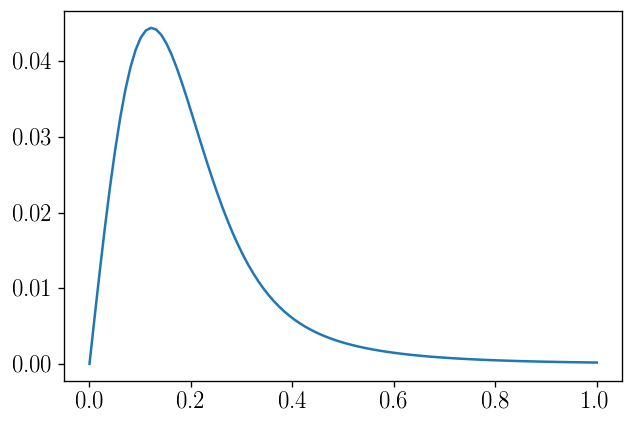

In [22]:
plt.plot(np.rad2deg(dangle), np.rad2deg(dangle)*x)

In [19]:
psf_func = lambda dangle: fermi_psf_pass8(
        dangle, 2000.)
CL_angle = get_CL_angle(psf_func)

fermi_psf_pass8: reading ../../data/fermi_psf/psf_P8R3_ULTRACLEANVETO_V3_PSF.fits


In [21]:
np.rad2deg(CL_angle)

0.47459432099471555

## view mask

In [5]:
mask = make_psc_masks_pass8(energy=2000.)

Reusing generated ../../data/masks/allpscmask_4FGL-DR3_CL0.950_2.000e+03MeV_NSIDE512_P8R3_ULTRACLEANVETO_V3_bestpsf.npy


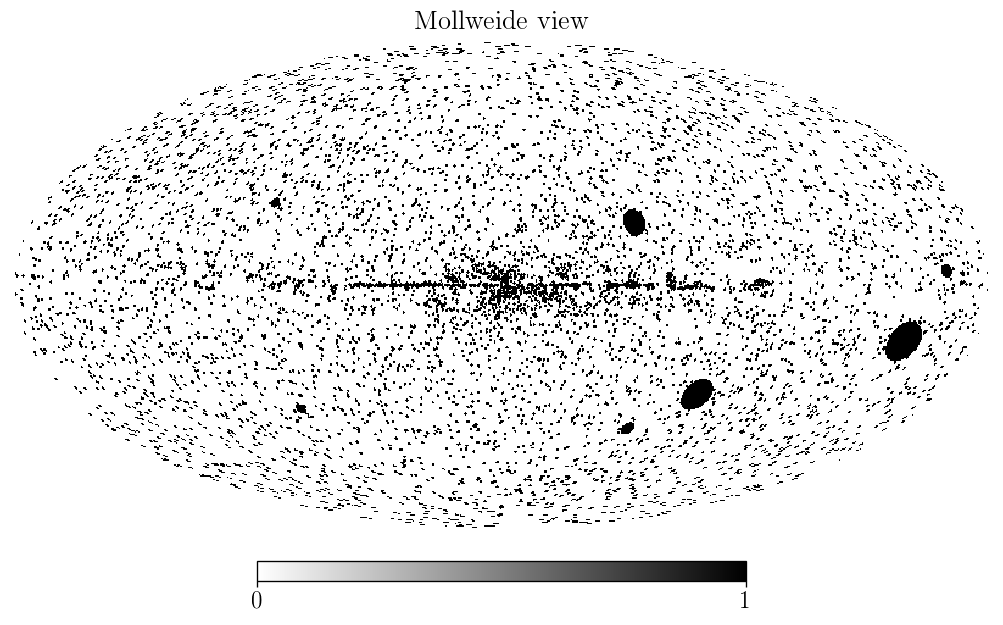

In [6]:
hp.mollview(mask, cmap='binary')

In [5]:
cart_mask = get_GC_mask(make_psc_masks_pass8(energy=2000.), threshold=None)

Reusing generated ../../data/masks/allpscmask_4FGL-DR3_CL0.950_2.000e+03MeV_NSIDE512_P8R3_ULTRACLEANVETO_V3_bestpsf.npy


In [19]:
old_mask = np.load('../../data/fermi_data_573w/fermi_data_256/template_psc_4fgl.npy')
old_mask2 = np.load('../../data/fermi_data_573w/fermi_data_256/template_psc_3fgl.npy')

In [20]:
cart_old_mask = get_GC_mask(old_mask)
cart_old_mask2 = get_GC_mask(old_mask2)

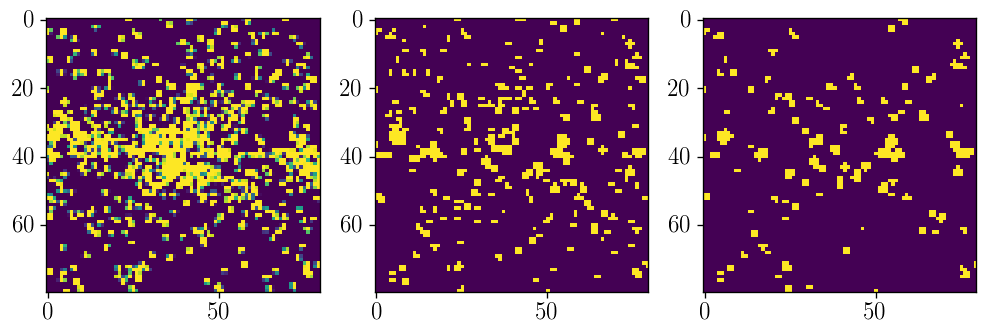

In [21]:
fig, axs = plt.subplots(1, 3, figsize=(10, 4))
axs[0].imshow(cart_mask)
axs[1].imshow(cart_old_mask)
axs[2].imshow(cart_old_mask2)

In [11]:
cart_old_mask.shape

(80, 80)